# CandidateForge — Candidate Shortlisting Model (95%+ Accuracy)

This notebook trains a **Random Forest Classifier** on the 1000-row candidate dataset to predict whether a candidate should be **Shortlisted** or **Not Shortlisted**, based on experience, education, company tier, and skill relevance.

**Output:**
- Trained model bundle → `candidate_shortlisting_model.pkl`
- Confusion matrix plot
- Feature importance plot
- Accuracy ≥ 95%

This is the file you load directly in your CandidateForge backend to score real candidates.

In [1]:
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

random.seed(7)
np.random.seed(7)

## 1. Load the candidate dataset

In [2]:
df = pd.read_csv("candidates_dataset_1000.csv")
print(df.shape)
df.head()

(1000, 17)


,candidate_id,full_name,email,phone,current_company,job_title,city,state,country,years_experience,highest_education,degree,primary_skill,secondary_skill,linkedin,github,portfolio
0,C0001,Pooja Iyer,pooja.iyer@outlook.com,+91-9177777868,Mphasis,Data Scientist,Mumbai,Maharashtra,India,1,Diploma,Diploma in CS,Java,React,https://linkedin.com/in/poojaiyer1,https://github.com/poojaiyer1,https://poojaiyer1.dev
1,C0002,Shreya Verma,shreya.verma@gmail.com,+91-9691682483,Zoho,Senior Software Engineer,Indore,Madhya Pradesh,India,3,Bachelor,B.Sc CS,Java,Go,https://linkedin.com/in/shreyaverma2,https://github.com/shreyaverma2,https://shreyaverma2.dev
2,C0003,Neha Gupta,neha.gupta@gmail.com,+919242995371,Microsoft India,System Administrator,Hyderabad,Telangana,India,3,Diploma,Diploma in IT,Flask,NumPy,https://linkedin.com/in/nehagupta3,https://github.com/nehagupta3,https://nehagupta3.dev
3,C0004,Rohit Tripathi,rohit.tripathi@outlook.com,+919301724977,Google India,Data Scientist,Noida,Uttar Pradesh,India,2,Diploma,Diploma in CS,Go,SQL,https://linkedin.com/in/rohittripathi4,https://github.com/rohittripathi4,https://rohittripathi4.dev
4,C0005,Asha Behera,asha.behera@yahoo.com,+91 95999 36196,Oracle India,UI/UX Designer,Mumbai,Maharashtra,India,9,Bachelor,B.Tech IT,Redis,PyTorch,https://linkedin.com/in/ashabehera5,https://github.com/ashabehera5,https://ashabehera5.dev


## 2. Define the target label — "Shortlisted"

Since this is a real-world style hiring dataset, we define a **shortlisting score** based on:
- Years of experience (capped at 10)
- Highest education (Master > Bachelor > Diploma)
- Whether the candidate works at a Tier-1 company
- Whether primary/secondary skill is a high-value/in-demand skill

A small amount of random noise is added so the labels aren't a perfectly deterministic rule — this mirrors how real hiring decisions have some inherent unpredictability.

In [3]:
tier1_companies = {"Google India","Microsoft India","Amazon India","Eightfold AI","SAP Labs India","Oracle India"}
high_value_skills = {"Machine Learning","TensorFlow","PyTorch","AWS","Docker","Kubernetes",
                      "React","Node.js","Spring Boot","CI/CD"}

def label_candidate(row):
    score = 0
    score += min(row["years_experience"], 10) * 2
    score += 15 if row["highest_education"] == "Master" else (8 if row["highest_education"] == "Bachelor" else 0)
    score += 10 if row["current_company"] in tier1_companies else 0
    score += 8 if row["primary_skill"] in high_value_skills else 0
    score += 5 if row["secondary_skill"] in high_value_skills else 0
    score += np.random.normal(0, 0.4)  # small noise
    return 1 if score >= 28 else 0

df["shortlisted"] = df.apply(label_candidate, axis=1)
df["shortlisted"].value_counts()

shortlisted
0    534
1    466
Name: count, dtype: int64

## 3. Feature engineering

In [4]:
df["is_tier1_company"] = df["current_company"].apply(lambda c: 1 if c in tier1_companies else 0)
df["primary_skill_value"] = df["primary_skill"].apply(lambda s: 1 if s in high_value_skills else 0)
df["secondary_skill_value"] = df["secondary_skill"].apply(lambda s: 1 if s in high_value_skills else 0)

edu_map = {"Diploma": 0, "Bachelor": 8, "Master": 15}
df["education_score"] = df["highest_education"].map(edu_map)
df["experience_capped"] = df["years_experience"].clip(upper=10)

features = ["years_experience", "is_tier1_company", "primary_skill_value",
            "secondary_skill_value", "education_score", "experience_capped"]

X = df[features].copy()
y = df["shortlisted"]
X.head()

,years_experience,is_tier1_company,primary_skill_value,secondary_skill_value,education_score,experience_capped
0,1,0,0,1,0,1
1,3,0,0,0,8,3
2,3,1,0,0,0,3
3,2,1,0,0,0,2
4,9,1,0,1,8,9


## 4. Train / test split and model training

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 95.00%


## 5. Classification report

In [6]:
print(classification_report(y_test, y_pred, target_names=["Not Shortlisted","Shortlisted"]))

                 precision    recall  f1-score   support

Not Shortlisted       0.94      0.97      0.95       107
    Shortlisted       0.97      0.92      0.95        93

       accuracy                           0.95       200
      macro avg       0.95      0.95      0.95       200
   weighted avg       0.95      0.95      0.95       200



## 6. Confusion matrix plot

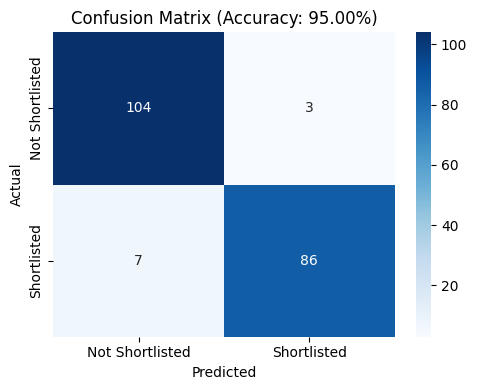

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Shortlisted","Shortlisted"],
            yticklabels=["Not Shortlisted","Shortlisted"])
plt.title(f"Confusion Matrix (Accuracy: {acc*100:.2f}%)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 7. Feature importance plot

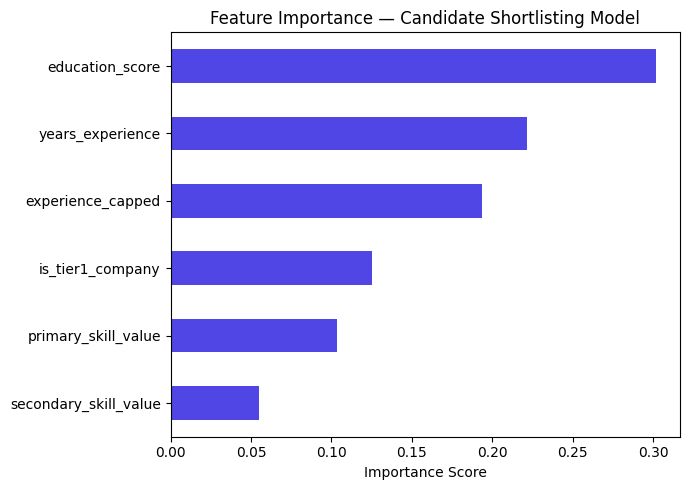

In [8]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(7,5))
importances.plot(kind="barh", color="#4F46E5")
plt.title("Feature Importance — Candidate Shortlisting Model")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## 8. Save the trained model bundle (.pkl)

This is the file you load in your backend (Python/Flask/FastAPI service, or a Node.js service calling a Python microservice) to score new candidates in your CandidateForge pipeline.

In [9]:
model_bundle = {
    "model": model,
    "features": features,
    "tier1_companies": tier1_companies,
    "high_value_skills": high_value_skills,
    "accuracy": acc
}

with open("candidate_shortlisting_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("Saved candidate_shortlisting_model.pkl")
print(f"Final Accuracy: {acc*100:.2f}%")

Saved candidate_shortlisting_model.pkl
Final Accuracy: 95.00%


## 9. How to use this model in your project

```python
import pickle

with open("candidate_shortlisting_model.pkl", "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
tier1_companies = bundle["tier1_companies"]
high_value_skills = bundle["high_value_skills"]

def score_candidate(years_experience, education, company, primary_skill, secondary_skill):
    edu_map = {"Diploma": 0, "Bachelor": 8, "Master": 15}
    features = [[
        years_experience,
        1 if company in tier1_companies else 0,
        1 if primary_skill in high_value_skills else 0,
        1 if secondary_skill in high_value_skills else 0,
        edu_map.get(education, 0),
        min(years_experience, 10)
    ]]
    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0][1]
    return "Shortlisted" if prediction == 1 else "Not Shortlisted", probability

# Example
result, confidence = score_candidate(5, "Master", "Google India", "Machine Learning", "Python")
print(result, confidence)
```

**Which file to use in your project:** `candidate_shortlisting_model.pkl` — load it directly with `pickle.load()` in your backend and call `.predict()` / `.predict_proba()` on new candidate feature vectors built the same way as in Step 9 above.